In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from calibration import pict_calibration, lifetime_to_temperature_201112
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
file_path = glob.glob('./center_3um/*/*.csv')
file_path.sort()

In [4]:
#t=0で切り取る
average_3um = 0
data_set_3um= pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    average_3um += temperature
    data_set_3um = pd.concat([data_set_3um, pd.DataFrame(temperature)], axis = 1)
    
average_3um = average_3um/len(file_path)
average_3um = average_3um - np.mean(average_3um[:10])

In [7]:
file_path = glob.glob('./center/*/*.csv')
file_path.sort()

In [8]:
#t=0で切り取る
average_10um = 0
data_set_10um = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    average_10um += temperature
    data_set_10um = pd.concat([data_set_10um, pd.DataFrame(temperature)], axis = 1)
    
average_10um = average_10um/len(file_path)
average_10um = average_10um - np.mean(average_10um[:10])

In [9]:
file_path = glob.glob('./center_5um/*/*.csv')
file_path.sort()

In [10]:
#t=0で切り取る
average_5um = 0
data_set_5um = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    average_5um += temperature
    data_set_5um = pd.concat([data_set_5um, pd.DataFrame(temperature)], axis = 1)
    
average_5um = average_5um/len(file_path)
average_5um = average_5um - np.mean(average_5um[:10])

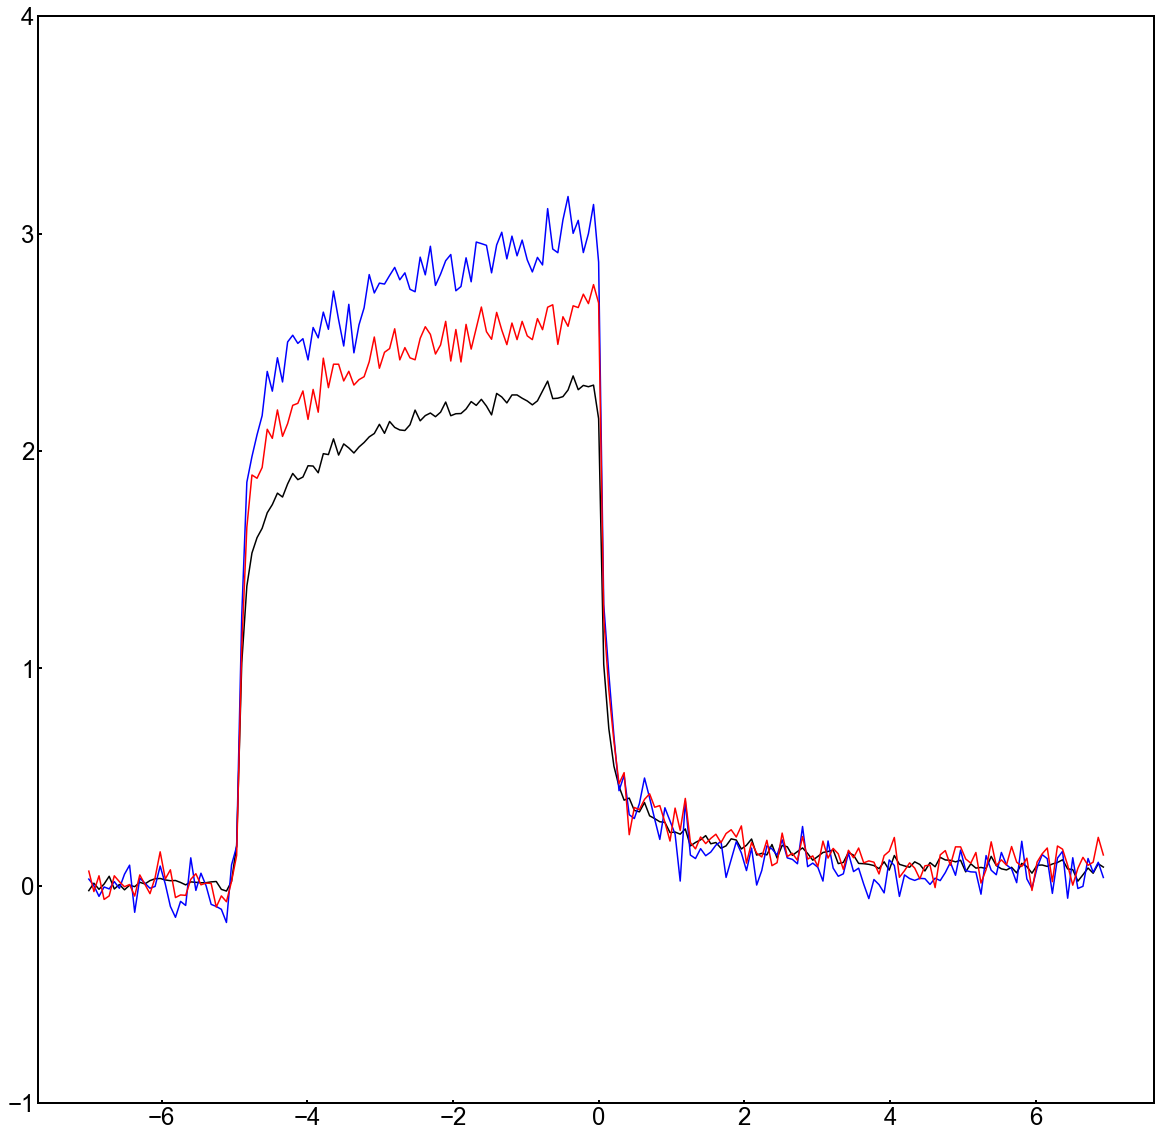

In [11]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time = [0.07*(i-100) for i in range(len(average_10um))]
plt.plot(time, average_10um, color = 'black')
plt.plot(time, average_3um, color = 'blue')
plt.plot(time, average_5um, color = 'red')
plt.ylim(-1, 4)
plt.show()

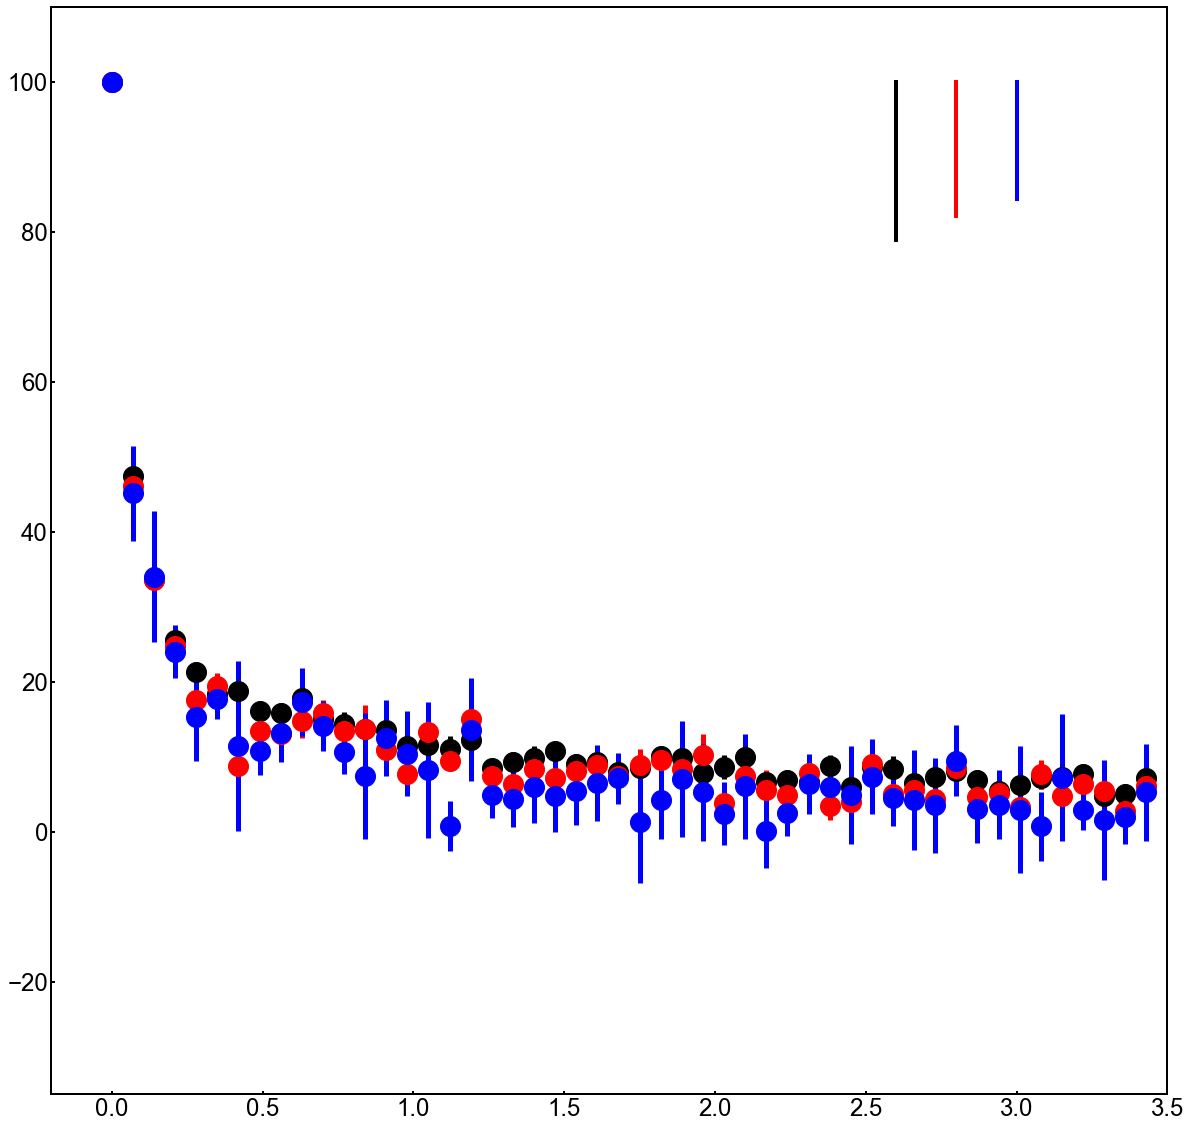

In [22]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)

average_10um_norm = average_10um[100:]/average_10um[100]
average_5um_norm = average_5um[100:]/average_5um[100]
average_3um_norm = average_3um[100:]/average_3um[100]

time_10um= [(i)*0.07 for i in range(len(average_10um_norm))]
time_5um = [(i)*0.07 for i in range(len(average_5um_norm))]
time_3um = [(i)*0.07 for i in range(len(average_3um_norm))]


#1˚Cを示すバーを挿入
ten_bar = [100- 50/max(average_10um)*i/100 for i in range(100)]
ten_bar_pos = [2.6 for i in range(len(ten_bar))]
plt.plot(ten_bar_pos, ten_bar, linewidth = 4, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
five_bar = [100- 50/max(average_5um)*i/100 for i in range(100)]
five_bar_pos = [2.8 for i in range(len(five_bar))]
plt.plot(five_bar_pos, five_bar, linewidth = 4, color = 'red', linestyle = '-')

#1˚Cを示すバーを挿入
three_bar = [100- 50/max(average_3um)*i/100 for i in range(100)]
three_bar_pos = [3.0 for i in range(len(three_bar))]
plt.plot(three_bar_pos, three_bar, linewidth = 4, color = 'blue', linestyle = '-')

#SEを計算
data_set_10um = data_set_10um - np.mean(data_set_10um.iloc[:10, :])
data_set_10um = data_set_10um/data_set_10um.iloc[100, :]*100
sem_10um = data_set_10um.sem(axis = 1)
sem_10um[0] = 0

#SEを計算
data_set_5um = data_set_5um - np.mean(data_set_5um.iloc[:10, :])
data_set_5um = data_set_5um/data_set_5um.iloc[100, :]*100
sem_5um = data_set_5um.sem(axis = 1)
sem_5um[0] = 0

#SEを計算
data_set_3um = data_set_3um - np.mean(data_set_3um.iloc[:10, :])
data_set_3um = data_set_3um/data_set_3um.iloc[100, :]*100
sem_3um = data_set_3um.sem(axis = 1)
sem_3um[0] = 0


#10um結果のプロット
plt.errorbar(time_10um[:50], average_10um_norm[:50]*100, yerr = np.ravel(sem_10um)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.plot(time_10um[:50], average_10um_norm[:50]*100, color = 'black', markersize = 20, marker = 'o', linewidth = 0)

#5um結果のプロット
plt.errorbar(time_5um[:50], average_5um_norm[:50]*100, yerr = np.ravel(sem_5um)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_5um[:50], average_5um_norm[:50]*100, color = 'red', markersize = 20, marker = 'o', linewidth = 0)

#3um結果のプロット
plt.errorbar(time_3um[:50], average_3um_norm[:50]*100, yerr = np.ravel(sem_3um)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='blue')
plt.plot(time_3um[:50], average_3um_norm[:50]*100, color = 'blue', markersize = 20, marker = 'o', linewidth = 0)

'''
#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
fitting_10um = curve_fit(relaxation, time_10um, average_10um_norm)[0]
fitting_5um = curve_fit(relaxation, time_5um, average_5um_norm)[0]
fitting_3um = curve_fit(relaxation, time_3um, average_3um_norm)[0]

#fitting結果の図示
plt.plot(time_10um[:50], relaxation(np.ravel(time_10um)[:50], fitting_10um[0], fitting_10um[1], fitting_10um[2])*100, color = 'black')
plt.plot(time_5um[:50], relaxation(np.ravel(time_5um)[:50], fitting_5um[0], fitting_5um[1], fitting_5um[2])*100, color = 'red')
plt.plot(time_3um[:50], relaxation(np.ravel(time_3um)[:50], fitting_3um[0], fitting_3um[1], fitting_3um[2])*100, color = 'red')
'''

plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)


#pdfのセーブ
pp = PdfPages('./Fig4d_decay.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(average_10um_norm*100).to_csv('relaxation_10um.csv')
pd.DataFrame(average_5um_norm*100).to_csv('relaxation_5um.csv')
pd.DataFrame(average_5um_norm*100).to_csv('relaxation_3um.csv')

pd.DataFrame(sem_10um[100:150]).to_csv('sem_10um.csv')
pd.DataFrame(sem_5um[100:150]).to_csv('sem_5um.csv')
pd.DataFrame(sem_3um[100:150]).to_csv('sem_3um.csv')

In [13]:
sum_10um = data_set_10um.iloc[102:150].sum().values
sum_5um = data_set_5um.iloc[102:150].sum().values
sum_3um = data_set_3um.iloc[102:150].sum().values

In [14]:
sem_10um_bar = (sum_10um*0.07).std(ddof = 1)/np.sqrt(len(sum_10um))
sem_5um_bar = (sum_5um*0.07).std(ddof = 1)/np.sqrt(len(sum_5um))
sem_3um_bar = (sum_3um*0.07).std(ddof = 1)/np.sqrt(len(sum_3um))

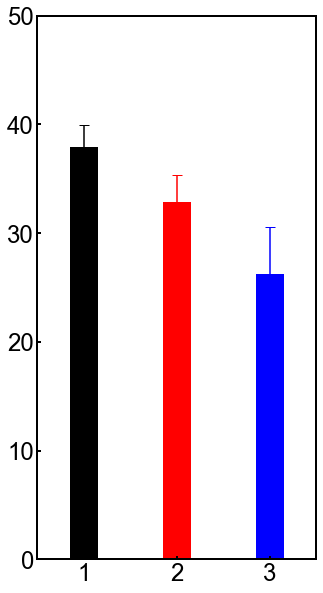

In [15]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_10um_ave = np.average(sum_10um*0.07)
sum_5um_ave = np.average(sum_5um*0.07)
sum_3um_ave = np.average(sum_3um*0.07)
plt.bar(1, sum_10um_ave, yerr = sem_10um_bar, capsize = 5, ecolor = 'black', width=0.3, color='black')
plt.bar(2, sum_5um_ave, yerr = sem_5um_bar, capsize = 5, ecolor = 'red', width=0.3, color='red')
plt.bar(3, sum_3um_ave, yerr = sem_3um_bar, capsize = 5, ecolor = 'blue', width=0.3, color='blue')
plt.ylim(0, 50)
plt.xlim(0.5, 3.5)

#pdfのセーブ
pp = PdfPages('./Fig4d_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

In [16]:
print(sum_10um_ave)
print(sum_5um_ave)
print(sum_3um_ave)

38.788803
32.85512
26.756777


In [6]:
1/(2.71828**4)

0.018315688169057598